# Síntesis de resultados

Este notebook consolida los hallazgos de los modelos geoestadísticos (Kriging) y de Machine Learning (Random Forest/XGBoost), compara su desempeño técnico y genera los archivos optimizados para la aplicación web (Parte 6).

### Objetivos:
1.  **Comparación de Modelos:** Evaluación cuantitativa (RMSE, R²) entre interpolación espacial y regresión multivariada.
2.  **Análisis de Coherencia:** Cruzar predicciones con clusters estadísticos (LISA) para validar coherencia territorial.

### Configuración e importaciones

In [1]:
# Librerías a utilizar
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Configuración visual
sns.set_context("notebook")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# --- RUTAS ---
BASE_DIR = Path('..')
OUTPUTS_DIR = BASE_DIR / 'outputs'
REPORTS_DIR = OUTPUTS_DIR / 'reports'
MODELS_DIR = OUTPUTS_DIR / 'models'
FIG_DIR = OUTPUTS_DIR / 'figures'

# Conexión BD (Para recuperar datos frescos si es necesario)
load_dotenv()
try:
    # Usamos 'postgis' como host asumiendo entorno Docker, si falla usa localhost
    host = os.getenv('POSTGRES_HOST', 'localhost')
    db_conn = f"postgresql://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}@{host}:5432/{os.getenv('POSTGRES_DB')}"
    engine = create_engine(db_conn)
    print("✔ Configuración lista.")
except:
    print("ERROR: No se pudo configurar la BD, se dependerá de archivos locales.")

✔ Configuración lista.


### Comparación de Modelos (Geoestadística vs ML)

,Enfoque,RMSE,R2
0,Geoestadística (Kriging),92.368552,0.195279
1,Machine Learning (RandomForest),102.445862,0.122509


✔ Gráfico comparativo guardado.


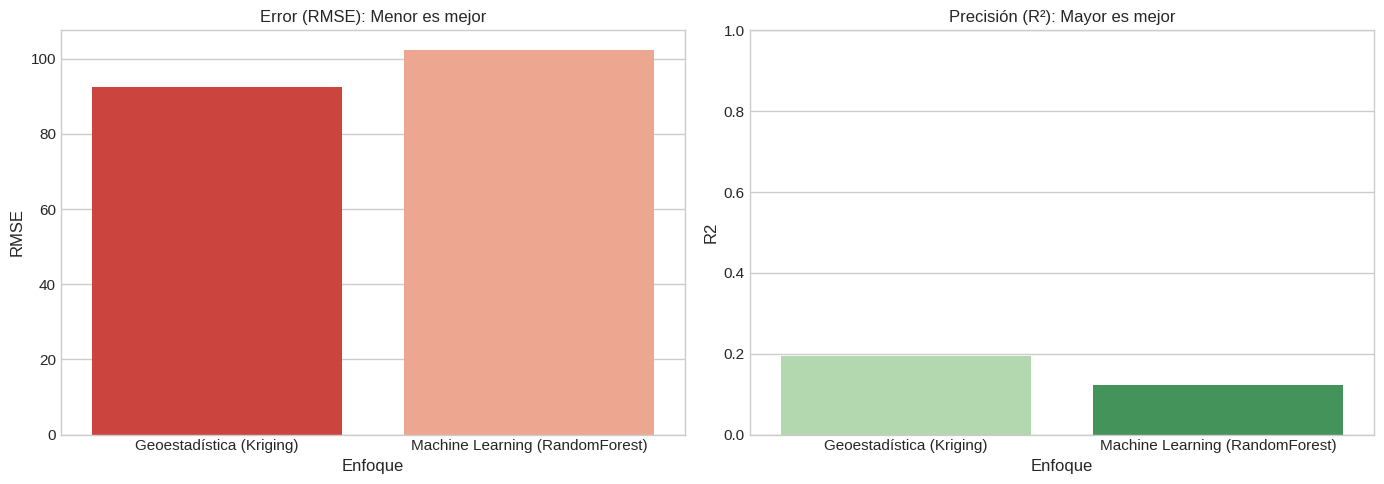

In [2]:
# --- COMPARACIÓN DE DESEMPEÑO: KRIGING VS MACHINE LEARNING ---

def load_and_compare_metrics():
    """
    Descripción: Función que carga los reportes de error generados en los notebooks 03 y 04.
    Y genera un gráfico de barras comparativo para definir el "Modelo Ganador".

    Salidas:
        None. Tabla comparativa y gráficos asociados a RMSE y R^2 (Kriging vs Random Forest)
    """
    metrics = []
    
    # 1. Métricas Geoestadísticas (Notebook 03)
    geo_path = REPORTS_DIR / 'cv_all_variables.csv'
    if geo_path.exists():
        df_geo = pd.read_csv(geo_path)
        # Filtramos para densidad poblacional y método Kriging
        kriging = df_geo[
            (df_geo['variable'] == 'pop_density') & 
            (df_geo['method'] == 'Kriging')
        ][['RMSE', 'R2']].mean()
        
        metrics.append({
            'Enfoque': 'Geoestadística (Kriging)',
            'RMSE': kriging['RMSE'],
            'R2': kriging['R2']
        })

    # 2. Métricas Machine Learning (Notebook 04)
    ml_path = REPORTS_DIR / 'model_comparison.csv'
    if ml_path.exists():
        df_ml = pd.read_csv(ml_path)
        best_ml = df_ml.iloc[0] 
        # Ajuste para obtener el nombre del modelo
        model_name = best_ml['model'] if 'model' in best_ml else df_ml.index[0]
        
        metrics.append({
            'Enfoque': f'Machine Learning ({model_name})',
            'RMSE': best_ml['RMSE'],
            'R2': best_ml['R2']
        })
    
    # 3. Graficar
    if metrics:
        df_metrics = pd.DataFrame(metrics)
        display(df_metrics)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # RMSE (Menor es mejor)
        sns.barplot(
            data=df_metrics, 
            x='Enfoque', 
            y='RMSE', 
            hue='Enfoque',  # Nuevo estándar de Seaborn
            ax=axes[0], 
            palette='Reds_r', 
            legend=False    # Evita duplicar la leyenda
        )
        axes[0].set_title('Error (RMSE): Menor es mejor')
        
        # R2 (Mayor es mejor)
        sns.barplot(
            data=df_metrics, 
            x='Enfoque', 
            y='R2', 
            hue='Enfoque',  # <--- Nuevo estándar de Seaborn
            ax=axes[1], 
            palette='Greens', 
            legend=False    # <--- Evita duplicar la leyenda
        )
        axes[1].set_title('Precisión (R²): Mayor es mejor')
        axes[1].set_ylim(0, 1)
        
        plt.tight_layout()
        plt.savefig(FIG_DIR / '05_sintesis_comparacion_modelos.png', dpi=300)
        print("✔ Gráfico comparativo guardado.")
    else:
        print("Error: No se encontraron archivos de reportes previos.")

load_and_compare_metrics()

### Síntesis y validación espacial

Reconstruyendo dataset para síntesis...
   ✔ Datos Vectoriales cargados (792 registros).
   Calculando estadísticas zonales (NDVI/Slope)...
Modelo aplicado: randomforest_pop_density.pkl
   ✔ Predicciones generadas exitosamente.
✔ Primeras filas del dataset sintetizado:


,fid,cut,region_x,provincia_x,comuna_x,nombre_distrito,codigo_distrito,manzent,zona_censal,manzana,...,area_ha,edif_density,amen_density,log_area,log_edif_density,log_amen_density,x_coord,y_coord,degree_mean,prediction_ml
0,31514,13129,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,SAN JOAQUÍN,SAN JOAQUÍN,1,13129011003023,3,23,...,4.101211,1.706813,0.487661,1.629478,0.995772,0.397205,348982.274635,6.295298e+06,0,87.386605
1,31515,13129,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,SAN JOAQUÍN,SAN JOAQUÍN,1,13129011002033,2,33,...,16.040837,2.555976,0.062341,2.835613,1.268630,0.060475,348625.346270,6.294962e+06,0,25.492492
2,31516,13129,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,SAN JOAQUÍN,SAN JOAQUÍN,1,13129011003022,3,22,...,7.831905,4.341217,1.021463,2.178371,1.675453,0.703821,349028.743743,6.295024e+06,0,38.125681
3,31517,13129,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,SAN JOAQUÍN,SAN JOAQUÍN,1,13129011002026,2,26,...,0.625942,23.963826,0.000000,0.486088,3.217428,0.000000,348350.855469,6.294929e+06,0,96.171355
4,31518,13129,REGIÓN METROPOLITANA DE SANTIAGO,SANTIAGO,SAN JOAQUÍN,SAN JOAQUÍN,1,13129011002024,2,24,...,0.591999,50.675661,1.689189,0.464991,3.944987,0.989240,348294.206468,6.294912e+06,0,155.126562



✔ Columnas disponibles:
['fid', 'cut', 'region_x', 'provincia_x', 'comuna_x', 'nombre_distrito', 'codigo_distrito', 'manzent', 'zona_censal', 'manzana', 'total_personas', 'total_hombres', 'total_mujeres', 'personas_0_a_5_años', 'personas_6_a_14_años', 'personas_15_a_64_años', 'personas_mas_65_años', 'personas_emigrantes', 'pueblos_indigena_originario', 'total_viv_particulares', 'total_viv_colectivas', 'viv_ocupa_morador_presente', 'total_viviendas', 'cantidad_hogares', 'viv_tipo_casa', 'viv_tipo_depto', 'viv_tipo_trad_indigena', 'viv_tipo_pieza', 'viv_tipo_mediagua', 'viv_tipo_movil', 'viv_tipo_otro_tipo', 'viv_pared_hormigon_armado', 'viv_pared_albañileria', 'viv_pared_tabique_forrado', 'viv_pared_tabique_sin_forro', 'viv_pared_adobe_barro', 'viv_pared_material_precario', 'viv_techo_tejas', 'viv_techo_losa_hormigon', 'viv_techo_planchas', 'viv_techo_fonolita', 'viv_techo_paja', 'viv_techo_mat_precarios', 'viv_techo_sin_cubierta_solida', 'viv_piso_parquet_flotante', 'viv_piso_radier',

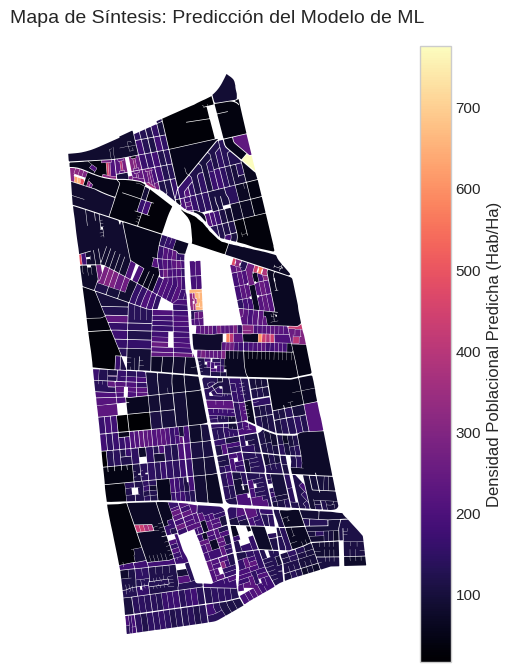

In [3]:
# --- ANÁLISIS DE COHERENCIA ESPACIAL ---

import rasterio
from rasterio.mask import mask
import numpy as np

# Función auxiliar para recuperar datos Raster (NDVI/Slope)
def calculate_zonal_stats(gdf, raster_path):
    """
    Descripción: Función que calcula el valor promedio de una capa raster (píxeles) dentro de cada geometría vectorial (manzana).
    Maneja la reproyección de coordenadas y casos de borde donde no hay datos.

    Entradas:
        gdf (GeoDataFrame): Capa vectorial con los polígonos de las manzanas.
        raster_path (str): Ruta al archivo .tif (ej: NDVI o Pendiente).

    Salidas:
        list: Lista de valores promedio (float) correspondientes a cada fila del GeoDataFrame.
    """
    # Verificar existencia del archivo
    if not os.path.exists(raster_path):
        print(f"ERROR: Archivo no encontrado: {raster_path}")
        return np.zeros(len(gdf))
        
    means = []
    # Abrir el archivo raster en modo lectura
    with rasterio.open(raster_path) as src:
        # Asegurar que el vectorial tenga la misma proyección que el raster
        if gdf.crs != src.crs:
            gdf_proj = gdf.to_crs(src.crs)
        else:
            gdf_proj = gdf
        # Iterar sobre cada polígono    
        for geom in gdf_proj.geometry:
            try:
                # Recortar el raster usando la geometría de la manzana (Masking)
                out_image, _ = mask(src, [geom], crop=True, nodata=np.nan)
                data = out_image[0]
                # Filtrar valores nulos (NaN) e infinitos para el promedio
                valid_data = data[np.isfinite(data)]
                if valid_data.size > 0:
                    means.append(np.mean(valid_data)) # Promedio real
                else:
                    means.append(0) # Si la manzana cae fuera del raster
            except:
                means.append(0) # Manejo de errores geométricos
    return means

def analyze_spatial_coherence():
    """
    Descripción: Función que reconstruye el dataset maestro integrando datos de SQL y archivos Raster.
    Carga el modelo de Machine Learning entrenado y genera predicciones para todas las manzanas.
    
    Entradas:
        None (Utiliza variables globales ENGINE y rutas de directorios).

    Salidas:
        GeoDataFrame: Dataset completo con la columna nueva 'prediction_ml'.
    """
    print("Reconstruyendo dataset para síntesis...")
    
    # 1. Cargar Geometrías y Atributos Vectoriales desde Base de Datos
    try:
        query = """
            SELECT m.*, n.road_density_km2, n.betweenness_mean, 
                   e.num_edificios, e.num_amenidades
            FROM processed_data.manzanas_atributos m
            LEFT JOIN processed_data.metrics_network n ON m.manzent::text = n.manzent::text
            LEFT JOIN processed_data.metrics_manzanas e ON m.manzent::text = e.manzent::text
        """
        
        gdf = gpd.read_postgis(query, engine, geom_col='geometry')
        print(f"   ✔ Datos Vectoriales cargados ({len(gdf)} registros).")
        
    except Exception as e:
        print(f"ERROR: Error SQL Crítico: {e}")
        return None

    # 2. Recuperar Variables Raster (Calculadas desde archivos .tif)
    print("   Calculando estadísticas zonales (NDVI/Slope)...")
    gdf['ndvi_mean'] = calculate_zonal_stats(gdf, '../data/processed/sentinel2_ndvi.tif')
    gdf['slope_mean'] = calculate_zonal_stats(gdf, '../data/processed/slope.tif')

    # 3. Preprocesamiento (Feature Engineering)
    # Proyección métrica
    if gdf.crs and gdf.crs.to_epsg() != 32719:
        gdf = gdf.to_crs(epsg=32719)
    # Calcular área en hectáreas    
    gdf['area_ha'] = gdf.geometry.area / 10000
    # Rellenar valores nulos con 0 para evitar errores matemáticos
    cols_to_fill = ['num_edificios', 'num_amenidades', 'area_ha', 'road_density_km2', 'betweenness_mean']
    for c in cols_to_fill:
        if c in gdf.columns:
            gdf[c] = gdf[c].fillna(0)
    # Calcular variables derivadas (Densidades)
    gdf['edif_density'] = gdf['num_edificios'] / (gdf['area_ha'] + 1e-6)
    gdf['amen_density'] = gdf['num_amenidades'] / (gdf['area_ha'] + 1e-6)
    
    # --- APLICAR TRANSFORMACIONES (Feature Engineering) ---
    # Usamos nombres explícitos para coincidir exactamente con el modelo entrenado del notebook 04
    gdf['log_area'] = np.log1p(gdf['area_ha'])          # ANTES: log_area_ha -> AHORA: log_area
    gdf['log_edif_density'] = np.log1p(gdf['edif_density'])
    gdf['log_amen_density'] = np.log1p(gdf['amen_density'])
        
    # Extraer coordenadas de centroides
    gdf['x_coord'] = gdf.geometry.centroid.x
    gdf['y_coord'] = gdf.geometry.centroid.y
    
    # 4. Cargar Modelo y Predecir
    try: # Buscar el archivo del modelo (.pkl) en la carpeta de modelos
        model_path = list(MODELS_DIR.glob('*pop_density.pkl'))[0]
        model = joblib.load(model_path)
        print(f"Modelo aplicado: {model_path.name}")

        # Definir la lista exacta de features que espera el modelo
        FEATURES = [
            'log_area',            # Morfología
            'road_density_km2',    # Conectividad
            'degree_mean',         # Red vial
            'betweenness_mean',    # Centralidad
            'ndvi_mean',           # Vegetación
            'slope_mean',          # Topografía
            'log_edif_density',    # Densidad edificada
            'log_amen_density',    # Servicios
            'x_coord',             # Posición X
            'y_coord'              # Posición Y
        ]
        
        # Validar si falta alguna columna (ej: degree_mean a veces es nulo)
        if 'degree_mean' not in gdf.columns:
            gdf['degree_mean'] = 0
            
        # Seleccionamos las columnas en el orden correcto
        X = gdf[FEATURES].fillna(0) # Crear matriz X ordenada y limpia
        # Generar predicción y guardarla en el GeoDataFrame
        gdf['prediction_ml'] = model.predict(X)
        print("   ✔ Predicciones generadas exitosamente.")
        
    except IndexError:
        print("ERROR: No se encontró modelo .pkl en outputs/models. Saltando predicción.")
        gdf['prediction_ml'] = 0
    except Exception as e:
        print(f"ERROR: Error al predecir: {e}")
        # Intento de depuración: ver qué columnas faltan
        # missing = [f for f in FEATURES if f not in gdf.columns]
        # if missing: print(f"   Columnas faltantes: {missing}")
        gdf['prediction_ml'] = 0
        
    return gdf

# --- EJECUCIÓN ---
# Ejecutar la función y guardar el resultado en memoria
gdf_final = analyze_spatial_coherence()

# --- VALIDACIÓN VISUAL DE RESULTADOS ---

# 1. Ver las primeras 5 filas de la tabla generada
print("✔ Primeras filas del dataset sintetizado:")
display(gdf_final.head())

# 2. Ver las columnas nuevas (Validar existencia de prediction_ml)
print("\n✔ Columnas disponibles:")
print(gdf_final.columns.tolist())

# 3. Visualizar el Mapa de Predicciones
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
gdf_final.plot(
    column='prediction_ml', 
    cmap='magma', 
    legend=True, 
    legend_kwds={'label': "Densidad Poblacional Predicha (Hab/Ha)"},
    ax=ax
)
ax.set_title("Mapa de Síntesis: Predicción del Modelo de ML", fontsize=14)
ax.set_axis_off()
plt.show()